In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def process_sentiment(sub_name):
    sent_map = {
        "positive": 1,
        "neutral": 0,
        "negative": -1}

    path = f"subs_sentiment/{sub_name}_sentiment.csv"
    df = pd.read_csv(path)
    df['sentiment'] = df['sentiment'].map(sent_map)
    df['log_pop'] = np.log(df['populairity']+1)
    df['log_pop'] = df['log_pop'] / df['log_pop'].max()
    df['time'] = pd.to_datetime(df['created_utc'], unit='s')
    df = df.set_index('time')
    df = df[['sentiment', 'log_pop']]
    df = df[df['sentiment']!=0]
    df = df[df['sentiment'].notna()]
    df['sentiment'] = df['sentiment'] * df['log_pop']
    df.sort_index(inplace=True)

    df = df.resample('h')['sentiment'].agg(['mean', 'std']).ffill().fillna(0)
    df.rename(columns={'mean': 'mean_sentiment', 'std': 'std_sentiment'}, inplace=True)

    # plt.plot(df.index, df['mean'])
    return df

In [63]:
from statsmodels.tsa.stattools import adfuller, kpss

result = adfuller(df['mean'])   # series must be a 1-D array or pandas Series

print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f"Critical Value {key}: {value}")

ADF Statistic: -9.105342771775838
p-value: 3.514955297435513e-15
Critical Value 1%: -3.435032872877345
Critical Value 5%: -2.863608153613473
Critical Value 10%: -2.5678710778146954


In [70]:
market_df = pd.read_csv('nfl_historic_candlestick_hour.csv')
market_df = market_df[['end_period_ts','price.close_dollars','price.high_dollars','price.low_dollars','market']].ffill()
market_df['event'] = market_df['market'].apply(lambda x: x.split('-')[1])
market_df['bet_team'] = market_df['market'].apply(lambda x: x.split('-')[2])
market_df['test_team'] = np.array([s[7:7+len] for s,len in zip(market_df['event'].to_numpy(), market_df['bet_team'].str.len())])
market_df['other_team'] = np.array([s[7:].replace(exclude, '') for s, exclude in zip(market_df['event'].to_numpy(), market_df['bet_team'])])
market_df['home_team'] = np.where(market_df['bet_team']==market_df['test_team'], market_df['bet_team'], market_df['other_team'])
market_df['away_team'] = np.array([s[7:].replace(exclude, '') for s, exclude in zip(market_df['event'].to_numpy(), market_df['home_team'])])
market_df.drop(['test_team','other_team'], axis=1, inplace=True)
market_df['game'] = market_df['market'].apply(lambda x: x.split('-')[1][2:7]+' - '+x.split('-')[1][7:10]+' vs '+x.split('-')[1][10:13])
market_df.drop('market', axis=1, inplace=True)
market_df['end_period_ts'] = pd.to_datetime(market_df['end_period_ts'], unit='s')
market_df['kalshi_close_home'] = np.where(market_df['bet_team']==market_df['home_team'], market_df['price.close_dollars'], 1 - market_df['price.close_dollars'])
market_df['kalshi_close_away'] = np.where(market_df['bet_team']==market_df['away_team'], market_df['price.close_dollars'], 1 - market_df['price.close_dollars'])
market_df['kalshi_high_home'] = np.where(market_df['bet_team']==market_df['home_team'], market_df['price.high_dollars'], 1 - market_df['price.high_dollars'])
market_df['kalshi_high_away'] = np.where(market_df['bet_team']==market_df['away_team'], market_df['price.high_dollars'], 1 - market_df['price.high_dollars'])
market_df['kalshi_low_home'] = np.where(market_df['bet_team']==market_df['home_team'], market_df['price.low_dollars'], 1 - market_df['price.low_dollars'])
market_df['kalshi_low_away'] = np.where(market_df['bet_team']==market_df['away_team'], market_df['price.low_dollars'], 1 - market_df['price.low_dollars'])
market_df = market_df[['end_period_ts','game','home_team', 'away_team','kalshi_close_home','kalshi_close_away','kalshi_high_home','kalshi_high_away','kalshi_low_home','kalshi_low_away']]
market_df = market_df.set_index(['end_period_ts', 'game'])
market_df = market_df[~market_df.index.duplicated(keep='first')]
market_df = market_df.reset_index()
market_df.drop('game', axis=1, inplace=True)
market_df = market_df.set_index('end_period_ts')
market_df.sort_index(inplace=True)
market_df = market_df.round(2)
market_df = market_df[market_df.index >=pd.to_datetime('2025-08-28')]
market_df = market_df.reset_index()
market_df

,end_period_ts,home_team,away_team,kalshi_close_home,kalshi_close_away,kalshi_high_home,kalshi_high_away,kalshi_low_home,kalshi_low_away
0,2025-08-29 05:00:00,DAL,PHI,0.25,0.75,0.25,0.75,0.23,0.77
1,2025-08-29 06:00:00,DAL,PHI,0.23,0.77,0.25,0.75,0.23,0.77
2,2025-08-29 07:00:00,DAL,PHI,0.25,0.75,0.25,0.75,0.25,0.75
3,2025-08-29 08:00:00,DAL,PHI,0.23,0.77,0.23,0.77,0.23,0.77
4,2025-08-29 09:00:00,DAL,PHI,0.25,0.75,0.25,0.75,0.25,0.75
...,...,...,...,...,...,...,...,...,...
22540,2025-11-04 00:00:00,ARI,DAL,0.36,0.64,0.36,0.64,0.38,0.62
22541,2025-11-04 01:00:00,ARI,DAL,0.36,0.64,0.36,0.64,0.37,0.63
22542,2025-11-04 02:00:00,ARI,DAL,0.62,0.38,0.28,0.72,0.67,0.33
22543,2025-11-04 03:00:00,ARI,DAL,0.82,0.18,0.48,0.52,0.84,0.16


In [67]:
subs_df = pd.read_csv('reddit_subs.csv')
subs_df.dropna(inplace=True)
subs_list = []
for _,row in subs_df.iterrows():
    sub_sent_df = process_sentiment(row['Subreddit'])
    sub_sent_df['team'] = row['Team']
    sub_sent_df = sub_sent_df.round(2)
    subs_list.append(sub_sent_df)

sub_sent_df = pd.concat(subs_list)
sub_sent_df_home = sub_sent_df.rename(columns={'mean_sentiment': 'mean_sentiment_home', 'std_sentiment': 'std_sentiment_home','team':'home_team'})
sub_sent_df_away = sub_sent_df.rename(columns={'mean_sentiment': 'mean_sentiment_away', 'std_sentiment': 'std_sentiment_away','team':'away_team'})

In [82]:
df = market_df.merge(sub_sent_df_home, left_on=['end_period_ts','home_team'], right_on=['time','home_team'], how='left')
df = df.merge(sub_sent_df_away, left_on=['end_period_ts','away_team'], right_on=['time','away_team'], how='left')
df.dropna(inplace=True)
df.set_index('end_period_ts', inplace=True)
df.to_csv('kalshi_reddit_sentiment_combined.csv', index=True)

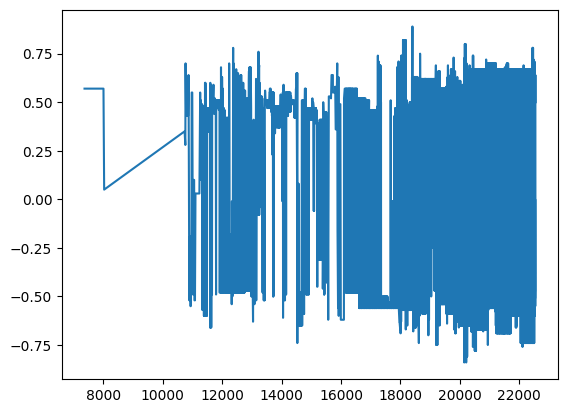

In [81]:
plt.plot(df.index, df['mean_sentiment_home'], label='Home Team Sentiment')